<a href="https://colab.research.google.com/github/bu11ymaguire/studying/blob/main/ReinforcementLearning/TemporalDifference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


class Renderer:
    def __init__(self, reward_map, goal_state, wall_state):
        self.reward_map = reward_map
        self.goal_state = goal_state
        self.wall_state = wall_state
        self.ys = len(self.reward_map)
        self.xs = len(self.reward_map[0])

        self.ax = None
        self.fig = None
        self.first_flg = True

    def set_figure(self, figsize=None):
        fig = plt.figure(figsize=figsize)
        self.ax = fig.add_subplot(111)
        ax = self.ax
        ax.clear()
        ax.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)
        ax.set_xticks(range(self.xs))
        ax.set_yticks(range(self.ys))
        ax.set_xlim(0, self.xs)
        ax.set_ylim(0, self.ys)
        ax.grid(True)

    def render_v(self, v=None, policy=None, print_value=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax

        if v is not None:
            color_list = ['red', 'white', 'green']
            cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
                'colormap_name', color_list)

            # dict -> ndarray
            v_dict = v
            v = np.zeros(self.reward_map.shape)
            for state, value in v_dict.items():
                v[state] = value

            vmax, vmin = v.max(), v.min()
            vmax = max(vmax, abs(vmin))
            vmin = -1 * vmax
            vmax = 1 if vmax < 1 else vmax
            vmin = -1 if vmin > -1 else vmin

            ax.pcolormesh(np.flipud(v), cmap=cmap, vmin=vmin, vmax=vmax)

        for y in range(ys):
            for x in range(xs):
                state = (y, x)
                r = self.reward_map[y, x]
                if r != 0 and r is not None:
                    txt = 'R ' + str(r)
                    if state == self.goal_state:
                        txt = txt + ' (GOAL)'
                    ax.text(x+.1, ys-y-0.9, txt)

                if (v is not None) and state != self.wall_state:
                    if print_value:
                        offsets = [(0.4, -0.15), (-0.15, -0.3)]
                        key = 0
                        if v.shape[0] > 7: key = 1
                        offset = offsets[key]
                        ax.text(x+offset[0], ys-y+offset[1], "{:12.2f}".format(v[y, x]))

                if policy is not None and state != self.wall_state:
                    actions = policy[state]
                    max_actions = [kv[0] for kv in actions.items() if kv[1] == max(actions.values())]

                    # Corrected arrows and offsets to match GridWorld's action_move_map:
                    # 0: UP, 1: DOWN, 2: RIGHT, 3: LEFT
                    arrows = ["↑", "↓", "→", "←"]
                    offsets = [(0, 0.1), (0, -0.1), (0.1, 0), (-0.1, 0)]
                    for action in max_actions:
                        arrow = arrows[action]
                        offset = offsets[action]
                        if state == self.goal_state:
                            continue
                        ax.text(x+0.45+offset[0], ys-y-0.5+offset[1], arrow)

                if state == self.wall_state:
                    ax.add_patch(plt.Rectangle((x,ys-y-1), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
        plt.show()

    def render_q(self, q, show_greedy_policy=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax
        action_space = [0, 1, 2, 3]

        qmax, qmin = max(q.values()), min(q.values())
        qmax = max(qmax, abs(qmin))
        qmin = -1 * qmax
        qmax = 1 if qmax < 1 else qmax
        qmin = -1 if qmin > -1 else qmin


        color_list = ['red', 'white', 'green']
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
            'colormap_name', color_list)

        for y in range(ys):
            for x in range(xs):
                for action in action_space:
                    state = (y, x)
                    r = self.reward_map[y, x]
                    if r != 0 and r is not None:
                        txt = 'R ' + str(r)
                        if state == self.goal_state:
                            txt = txt + ' (GOAL)'
                        ax.text(x+.05, ys-y-0.95, txt)

                    if state == self.goal_state:
                        continue

                    tx, ty = x, ys-y-1

                    # Corrected action_map and offset_map to match GridWorld's action_move_map:
                    # 0: UP, 1: DOWN, 2: RIGHT, 3: LEFT
                    action_map = {
                        0: ((0.5+tx, 0.5+ty), (tx+1, ty+1), (tx, ty+1)), # Up triangle
                        1: ((tx, ty), (tx+1, ty), (tx+0.5, ty+0.5)),    # Down triangle
                        2: ((0.5+tx, 0.5+ty), (tx+1, ty), (tx+1, ty+1)), # Right triangle (originally for action 3)
                        3: ((tx, ty), (tx+0.5, ty+0.5), (tx, ty+1)),    # Left triangle (originally for action 2)
                    }
                    offset_map = {
                        0: (0.1, 0.8),
                        1: (0.1, 0.1),
                        2: (0.4, 0.4), # Right offset (originally for action 3)
                        3: (-0.2, 0.4), # Left offset (originally for action 2)
                    }
                    if state == self.wall_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
                    elif state in self.goal_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0., 1., 0., 1.)))
                    else:

                        tq = q[(state, action)]
                        color_scale = 0.5 + (tq / qmax) / 2  # normalize: 0.0-1.0

                        poly = plt.Polygon(action_map[action],fc=cmap(color_scale))
                        ax.add_patch(poly)

                        offset= offset_map[action]
                        ax.text(tx+offset[0], ty+offset[1], "{:12.2f}".format(tq))
        plt.show()

        if show_greedy_policy:
            policy = {}
            for y in range(self.ys):
                for x in range(self.xs):
                    state = (y, x)
                    qs = [q[state, action] for action in range(4)]  # action_size
                    max_action = np.argmax(qs)
                    probs = {0:0.0, 1:0.0, 2:0.0, 3:0.0}
                    probs[max_action] = 1
                    policy[state] = probs
            self.render_v(None, policy)

In [2]:
# Monkey-patching the render_v method to fix NameError
import types
def fixed_render_v(self, v=None, policy=None, print_value=True):
    # This version directly calls Renderer instead of gridworld_render.Renderer
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_v(v, policy, print_value)

In [3]:
import numpy as np

class GridWorld:
  def __init__(self):
    self.action_space = [0,1,2,3]
    self.action_meaning = {
        0: "UP",
        1: "DOWN",
        2: "LEFT",
        3: "RIGHT"
    }

    self.reward_map = np.array(
        [[0,0,0,1.0],
         [0,None,0,-1.0],
            [0,0,0,0]
        ]
    )

    self.goal_state = (0,3) #목표 지점
    self.wall_state = (1,1) #벽
    self.start_state = (2,0) #시작 지점
    self.agent_state = self.start_state

  @property
  def height(self):
    return len(self.reward_map)

  @property
  def width(self):
    return len(self.reward_map[0])

  @property
  def shape(self):
    return self.reward_map.shape

  def actions(self):
    return self.action_space

  def states(self):
    for h in range(self.height):
      for w in range(self.width):
        yield(h,w)

  def next_state(self, state, action):
    action_move_map = [(-1,0),(1,0),(0,1),(0,-1)]
    move = action_move_map[action]
    next_state = (state[0]+ move[0],state[1] + move[1])
    ny, nx = next_state

    if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height: #이동하게 될 위치가 영역의 밖인 경우?
      next_state = state
    elif next_state == self.wall_state: #이동하게 될 위치가 벽인 경우
      next_state = state

    return next_state

  def reward(self, state, action, next_state):
    return self.reward_map[next_state]

  def render_v(self, v=None, policy=None, print_value=True):
        renderer = gridworld_render.Renderer(self.reward_map, self.goal_state,
                                          self.wall_state)
        renderer.render_v(v, policy, print_value)

In [4]:
from collections import defaultdict
import numpy as np
import random

class TdAgent:
  def __init__(self):
    self.gamma = 0.9
    self.alpha = 0.01
    self.action_size = 4

    random_actions = {0:0.25,1:0.25,2:0.25,3:0.25}
    self.pi = defaultdict(lambda: random_actions)
    self.V = defaultdict(lambda: 0)

  def get_action(self, state):
    action_probs = self.pi[state]
    actions = list(action_probs.keys())
    probs = list(action_probs.values())

    return np.random.choice(actions, p = probs)

  def eval(self, state, reward, next_state, done):
    next_V = 0 if done else self.V[next_state]
    target = reward + self.gamma * next_V

    self.V[state] += (target - self.V[state]) * self.alpha

In [5]:
def argmax(d):
  max_value = max(d.values())
  max_key = 0
  for key, value in d.items():
    if value == max_value:
          max_key = key
  return max_key

In [6]:
def greedy_policy(V, env, gamma):
  pi = {}

  for state in env.states():
    action_values = {}

    for action in env.actions():
      next_state = env.next_state(state, action)
      r = env.reward(state, action, next_state)
      value = r + gamma * V[next_state] # r(s,a,s') + γ * v_π(s')
      action_values[action] = value

    max_action = argmax(action_values) # 가치 함수가 가장 큰 행동 찾기
    action_probs = {0:0,1:0,2:0,3:0}
    action_probs[max_action] = 1.0
    pi[state] = action_probs # max_action의 확률을 1로 만들어서, 결정적인 정책 만들기

  return pi

In [7]:
def policy_iter(env,gamma, threshold = 0.001, is_render = False):
  pi = defaultdict(lambda: {0:0.25, 1:0.25, 2:0.25, 3:0.25})
  V = defaultdict(lambda : 0)

  while(True):
    V = policy_eval(pi, V, env, gamma, threshold)
    new_pi = greedy_policy(V, env, gamma)

    if is_render:
      env.render_v(V, new_pi)

    if pi == new_pi:
      break
    pi = new_pi

  return pi

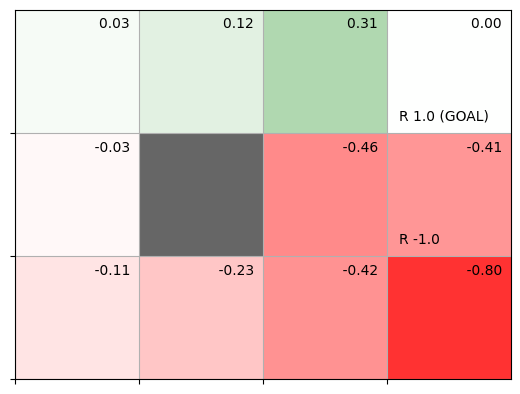

In [8]:
import types

env = GridWorld()
agent = TdAgent()

# Monkey-patching GridWorld instance with reset and step methods
def reset_method(self):
    self.agent_state = self.start_state
    return self.agent_state

def step_method(self, action):
    state = self.agent_state
    next_s = self.next_state(state, action)
    r = self.reward(state, action, next_s)
    done = (next_s == self.goal_state)
    self.agent_state = next_s
    return next_s, r, done

# Definition of fixed_render_v, copied from cell vQRb2f3tM7kE
def fixed_render_v(self, v=None, policy=None, print_value=True):
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_v(v, policy, print_value)

env.reset = types.MethodType(reset_method, env)
env.step = types.MethodType(step_method, env)
env.render_v = types.MethodType(fixed_render_v, env) # Apply the fix for render_v

episodes = 1000

for episode in range(episodes):
  state = env.reset()

  while True:
    action = agent.get_action(state)
    next_state, reward, done = env.step(action)

    agent.eval(state, reward, next_state, done)

    if done:
      break
    state = next_state

env.render_v(agent.V)

#SARSA법: On-Policy에서 S_t, A_t, R_t, S_t+1, A_t+1

In [9]:
from collections import defaultdict, deque

def greedy_policy(V, env, gamma):
  pi = {}

  for state in env.states():
    action_values = {}

    for action in env.actions():
      next_state = env.next_state(state, action)
      r = env.reward(state, action, next_state)
      value = r + gamma * V[next_state] # r(s,a,s') + γ * v_π(s')
      action_values[action] = value

    max_action = argmax(action_values) # 가치 함수가 가장 큰 행동 찾기
    action_probs = {0:0,1:0,2:0,3:0}
    action_probs[max_action] = 1.0
    pi[state] = action_probs # max_action의 확률을 1로 만들어서, 결정적인 정책 만들기

  return pi

In [10]:
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = argmax(qs)  # OR np.argmax(qs)
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

In [11]:
class SarsaAgent:
  def __init__(self):
    self.gamma = 0.9
    self.alpha = 0.8
    self.epsilon = 0.1
    self.action_size = 4

    random_actions = {0:0.25,1:0.25,2:0.25,3:0.25}
    self.pi = defaultdict(lambda: random_actions)
    self.Q = defaultdict(lambda: 0)
    self.memory = deque(maxlen = 2) #가장 최근 데이터 2개만 보관

  def get_action(self, state):
    action_probs = self.pi[state]
    actions = list(action_probs.keys())
    probs = list(action_probs.values())
    return np.random.choice(actions, p = probs)

  def reset(self):
    self.memory.clear()

  def update(self,state, action, reward, done):
    self.memory.append((state,action,reward,done))
    if len(self.memory) < 2:
      return

    state, action, reward, done = self.memory[0]
    next_state, next_action, _, _ = self.memory[1]

    next_q = 0 if done else self.Q[next_state, next_action]

    target = reward + self.gamma * next_q
    self.Q[state, action] += (target - self.Q[state,action]) * self.alpha

    self.pi[state] = greedy_probs(self.Q, state, self.epsilon)

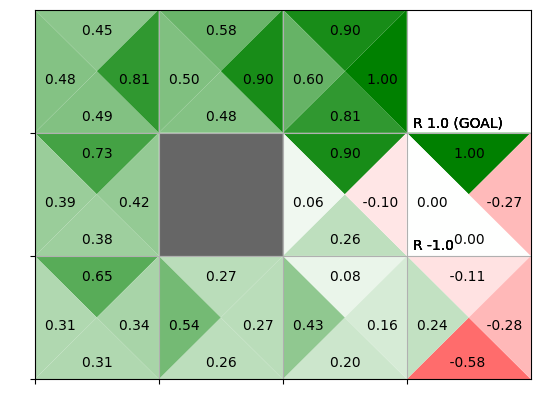

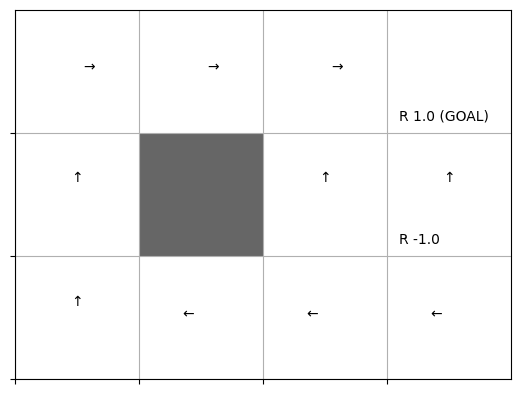

In [12]:
import types
import numpy as np # Ensure numpy is available for np.argmax

env = GridWorld()
agent = SarsaAgent()


# Monkey-patching GridWorld instance with reset and step methods
def reset_method(self):
    self.agent_state = self.start_state
    return self.agent_state

def step_method(self, action):
    state = self.agent_state
    next_s = self.next_state(state, action)
    r = self.reward(state, action, next_s)
    done = (next_s == self.goal_state)
    self.agent_state = next_s
    return next_s, r, done

# Definition of fixed_render_v, copied from cell vQRb2f3tM7kE
def fixed_render_v(self, v=None, policy=None, print_value=True):
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_v(v, policy, print_value)

# Define fixed_render_q to render Q-values using the Renderer class
def fixed_render_q(self, q, show_greedy_policy=True):
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_q(q, show_greedy_policy)

env.reset = types.MethodType(reset_method, env)
env.step = types.MethodType(step_method, env)
env.render_v = types.MethodType(fixed_render_v, env) # Apply the fix for render_v
env.render_q = types.MethodType(fixed_render_q, env) # Apply the fix for render_q

# Redefine greedy_probs within this cell to use np.argmax
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs) # Use np.argmax for lists
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}
    action_probs[max_action] += (1 - epsilon)
    return action_probs


episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while (True):
      action = agent.get_action(state)
      next_state, reward, done = env.step(action)

      agent.update(state, action, reward, done)

      if done:
        agent.update(next_state, None, reward, done)
        break

      state = next_state

env.render_q(agent.Q)

##오프 정책 SARSA

In [13]:
class SarsaOffPolicyAgent:
  def __init__(self):
    self.gamma = 0.9
    self.alpha = 0.8
    self.epsilon = 0.1
    self.action_size = 4

    random_actions = {0:0.25,1:0.25,2:0.25,3:0.25}
    self.pi = defaultdict(lambda: random_actions)
    self.b = defaultdict(lambda: random_actions)
    self.Q = defaultdict(lambda: 0)
    self.memory = deque(maxlen = 2)

  def get_action(self, state):
    action_probs = self.b[state]
    actions = list(action_probs.keys())
    probs = list(action_probs.values())
    return np.random.choice(actions, p = probs)

  def reset(self):
    self.memory.clear()

  def update(self, state, action, reward, done):
    self.memory.append((state, action, reward, done))
    if len(self.memory) < 2:
      return

    state, action, reward, done = self.memory[0]
    next_state, next_action, _, _ = self.memory[1]

    if done:
      next_q = 0
      rho = 1
    else:
      next_q = self.Q[next_state, next_action]
      rho = self.pi[next_state][next_action] / self.b[next_state][next_action]

    target = rho * (reward + self.gamma * next_q)
    self.Q[state, action] += (target - self.Q[state,action]) * self.alpha

    self.pi[state] = greedy_probs(self.Q, state, 0)
    self.b[state] = greedy_probs(self.Q, state, self.epsilon)

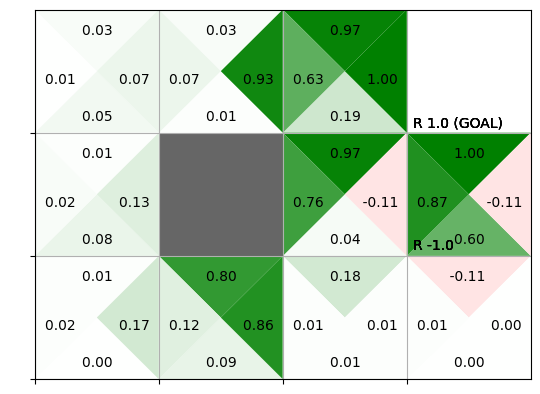

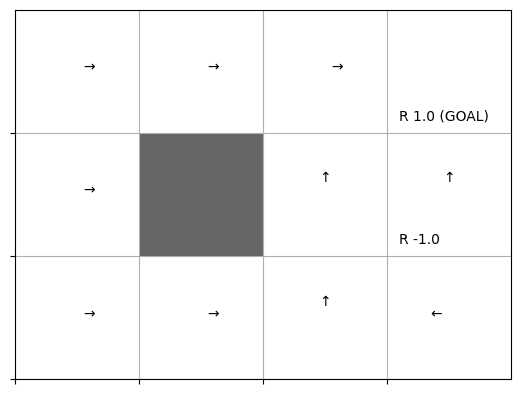

In [14]:
import types
import numpy as np # Ensure numpy is available for np.argmax

env = GridWorld()
agent = SarsaOffPolicyAgent()

# Monkey-patching GridWorld instance with reset and step methods
def reset_method(self):
    self.agent_state = self.start_state
    return self.agent_state

def step_method(self, action):
    state = self.agent_state
    next_s = self.next_state(state, action)
    r = self.reward(state, action, next_s)
    done = (next_s == self.goal_state)
    self.agent_state = next_s
    return next_s, r, done

# Definition of fixed_render_v, copied from cell vQRb2f3tM7kE
def fixed_render_v(self, v=None, policy=None, print_value=True):
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_v(v, policy, print_value)

# Define fixed_render_q to render Q-values using the Renderer class
def fixed_render_q(self, q, show_greedy_policy=True):
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_q(q, show_greedy_policy)

env.reset = types.MethodType(reset_method, env)
env.step = types.MethodType(step_method, env)
env.render_v = types.MethodType(fixed_render_v, env) # Apply the fix for render_v
env.render_q = types.MethodType(fixed_render_q, env) # Apply the fix for render_q

# Redefine greedy_probs within this cell to use np.argmax
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs) # Use np.argmax for lists
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}
    action_probs[max_action] += (1 - epsilon)
    return action_probs


episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while (True):
      action = agent.get_action(state)
      next_state, reward, done = env.step(action)

      agent.update(state, action, reward, done)

      if done:
        agent.update(next_state, None, reward, done)
        break

      state = next_state

env.render_q(agent.Q)

## Q러닝

In [25]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)

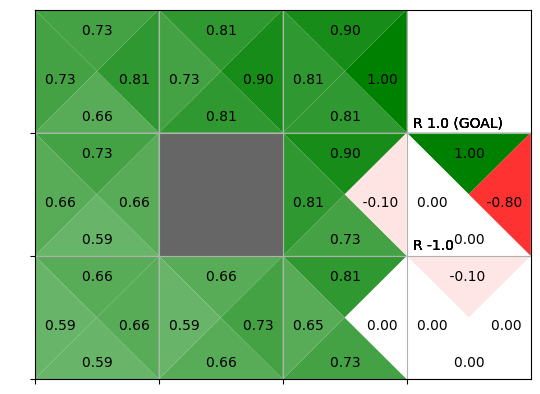

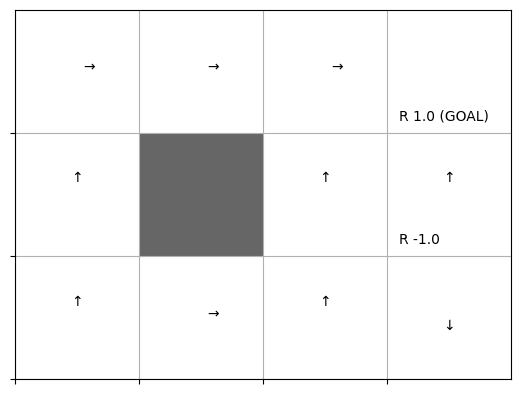

In [26]:
import types
import numpy as np # Ensure numpy is available for np.argmax

env = GridWorld()
agent = QLearningAgent()

# Monkey-patching GridWorld instance with reset and step methods
def reset_method(self):
    self.agent_state = self.start_state
    return self.agent_state

def step_method(self, action):
    state = self.agent_state
    next_s = self.next_state(state, action)
    r = self.reward(state, action, next_s)
    done = (next_s == self.goal_state)
    self.agent_state = next_s
    return next_s, r, done

# Definition of fixed_render_v, copied from cell vQRb2f3tM7kE
def fixed_render_v(self, v=None, policy=None, print_value=True):
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_v(v, policy, print_value)

# Define fixed_render_q to render Q-values using the Renderer class
def fixed_render_q(self, q, show_greedy_policy=True):
    renderer = Renderer(self.reward_map, self.goal_state,
                                      self.wall_state)
    renderer.render_q(q, show_greedy_policy)

env.reset = types.MethodType(reset_method, env)
env.step = types.MethodType(step_method, env)
env.render_v = types.MethodType(fixed_render_v, env) # Apply the fix for render_v
env.render_q = types.MethodType(fixed_render_q, env) # Apply the fix for render_q

# Redefine greedy_probs within this cell to use np.argmax, as it's used by QLearningAgent
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs) # Use np.argmax for lists
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

episodes = 10000

for episode in range(episodes):
  state = env.reset()

  while True:
    action = agent.get_action(state)
    next_state, reward, done = env.step(action)

    agent.update(state, action, reward, next_state, done)
    if done:
      break
    state = next_state


env.render_q(agent.Q)

## 분포모델